In [1]:
import pandas as pd
import os
import random
from sklearn.model_selection import train_test_split
import re
import sys
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, confusion_matrix
import torch.nn.functional as F

In [28]:
# Write the folder name only once
data_folder = "res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0"


# Choose how many tickers to use
# Set to None if you want all tickers
MAX_TICKERS = 400

# Make ticker selection reproducible
TICKER_SEED = 42

# Build paths from that
csv_path = os.path.join(data_folder, "labels.csv")

# Load csv
df = pd.read_csv(csv_path)

# Convert dates
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

# Use end_date as the observation date for splitting
df["date"] = df["end_date"]

# --------------------------------------------------
# LIMIT NUMBER OF TICKERS EARLY IN THE FILE
# --------------------------------------------------
all_tickers = sorted(df["ticker"].unique())
print(f"Total tickers available before filtering: {len(all_tickers)}")

if MAX_TICKERS is not None:
    if MAX_TICKERS > len(all_tickers):
        raise ValueError(
            f"MAX_TICKERS={MAX_TICKERS} is larger than the number of available tickers ({len(all_tickers)})."
        )

    rng = random.Random(TICKER_SEED)
    selected_tickers = rng.sample(all_tickers, MAX_TICKERS)
    selected_tickers = sorted(selected_tickers)

    df = df[df["ticker"].isin(selected_tickers)].copy()
    print(f"Using {len(selected_tickers)} tickers: {selected_tickers[:10]}{' ...' if len(selected_tickers) > 10 else ''}")

print(f"Rows after ticker filtering: {len(df)}")
print(df["ticker"].nunique(), "unique tickers remain")

print(df.head())
print(df.info())
print(df["label"].value_counts())

Total tickers available before filtering: 500
Using 400 tickers: ['A', 'AAPL', 'ABBV', 'ABT', 'ACN', 'ADM', 'ADP', 'ADSK', 'AEM', 'AEP'] ...
Rows after ticker filtering: 98006
400 unique tickers remain
                                          image_path ticker start_date  \
0  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...      A 2020-01-24   
1  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...      A 2020-01-31   
2  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...      A 2020-02-07   
3  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...      A 2020-02-14   
4  res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0...      A 2020-02-24   

    end_date  close_now  close_future  label       date  
0 2020-01-30      84.38         84.82      1 2020-01-30  
1 2020-02-06      84.82         85.47      1 2020-02-06  
2 2020-02-13      85.47         85.07      0 2020-02-13  
3 2020-02-21      85.07         77.07      0 2020-02-21  
4 2020-02-28      77.07         78.56      1 2020-02-28  
<clas

Tjekker at Billederne eksistere og fjerner rækker hvor billeder ikke eksisterer

In [29]:
df["file_exists"] = df["image_path"].apply(os.path.exists)

print(df["file_exists"].value_counts())

# Keep only rows where the image exists
df = df[df["file_exists"]].copy()

file_exists
True    98006
Name: count, dtype: int64


Sorterer data efter tid, så rækker der tilhører samme Ticker/firma ikke længere kommer efter hinanden. Det er fordi man i Finans verden gerne vil bruge gammel data til at forudsige ny data. Altså skal rækker med samme Ticker/firma ikke ligge sammen. Derimod skal den træne gammel data fra alle de forskellige Firmaer.

In [30]:
df = df.sort_values("date").reset_index(drop=True)
print(len(df))

98006


Step 5: Split by unique dates, not by rows

This is important. Since many companies share the same dates, it is better to split by the set of unique dates.

In [31]:
# Make sure dates are sorted only for reporting
unique_dates = sorted(df["date"].unique())

# First split full sample into train+val and test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,         # 15% test
    random_state=42,
    stratify=df["label"]
)

# Then split train+val into train and validation
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.30,         # 30% of train_val goes to validation
    random_state=42,
    stratify=train_val_df["label"]
)

# Optional: reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

Train shape: (58313, 9)
Val shape:   (24992, 9)
Test shape:  (14701, 9)

Date ranges:
Train: 2020-01-30 00:00:00 to 2024-12-23 00:00:00
Val:   2020-01-30 00:00:00 to 2024-12-19 00:00:00
Test:  2020-01-30 00:00:00 to 2024-12-20 00:00:00


In [ ]:
# # Make sure dates are sorted
# unique_dates = sorted(df["date"].unique())
# n_dates = len(unique_dates)

# # Keep the last 15% of dates as the out-of-sample test period
# test_start = int(n_dates * 0.85)
# dev_dates = unique_dates[:test_start]
# test_dates = unique_dates[test_start:]

# # Development sample = all rows before test period
# dev_df = df[df["date"].isin(dev_dates)].copy()
# test_df = df[df["date"].isin(test_dates)].copy()

# # Randomly split development sample into train/val
# # stratify=dev_df["label"] helps keep label balance similar in both
# train_df, val_df = train_test_split(
#     dev_df,
#     test_size=0.30,          # Jiang uses 70/30 train/val inside development sample
#     random_state=42,
#     stratify=dev_df["label"] # denne linje søger for at fordeling af op/ned labels er det samme i validation og training set.
# )

# # Optional: reset index
# train_df = train_df.reset_index(drop=True)
# val_df = val_df.reset_index(drop=True)
# test_df = test_df.reset_index(drop=True)

# print("Train shape:", train_df.shape)
# print("Val shape:  ", val_df.shape)
# print("Test shape: ", test_df.shape)

# print("\nDate ranges:")
# print("Train:", train_df["date"].min(), "to", train_df["date"].max())
# print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
# print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

Train shape: (59079, 9)
Val shape:   (25320, 9)
Test shape:  (13607, 9)

Date ranges:
Train: 2020-01-30 00:00:00 to 2024-04-17 00:00:00
Val:   2020-01-30 00:00:00 to 2024-04-17 00:00:00
Test:  2024-04-18 00:00:00 to 2024-12-23 00:00:00


In [32]:
print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

print("\nNumber of tickers:")
print("Train:", train_df["ticker"].nunique())
print("Val:  ", val_df["ticker"].nunique())
print("Test: ", test_df["ticker"].nunique())


Date ranges:
Train: 2020-01-30 00:00:00 to 2024-12-23 00:00:00
Val:   2020-01-30 00:00:00 to 2024-12-19 00:00:00
Test:  2020-01-30 00:00:00 to 2024-12-20 00:00:00

Number of tickers:
Train: 400
Val:   400
Test:  400


In [33]:
train_label_balance = train_df["label"].mean()
val_label_balance   = val_df["label"].mean()
test_label_balance  = test_df["label"].mean()

print("\nLabel balance:")
print(f"Train up: {train_label_balance:.1%}")
print(f"Val up:   {val_label_balance:.1%}")
print(f"Test up:  {test_label_balance:.1%}")


Label balance:
Train up: 54.4%
Val up:   54.4%
Test up:  54.4%


In [8]:
print(sys.executable)

c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe


In [34]:
folder_name = os.path.basename(data_folder)

match = re.match(r"res_(\d+)_(color|grayscale)", folder_name)
if not match:
    raise ValueError(f"Could not read resolution/color mode from folder name: {folder_name}")

IMG_RESOLUTION = int(match.group(1))
COLOR_MODE = match.group(2)

PIL_MODE = "RGB" if COLOR_MODE == "color" else "L"
INPUT_CHANNELS = 3 if COLOR_MODE == "color" else 1

print("IMG_RESOLUTION:", IMG_RESOLUTION)
print("COLOR_MODE:", COLOR_MODE)
print("PIL_MODE:", PIL_MODE)
print("INPUT_CHANNELS:", INPUT_CHANNELS)

IMG_RESOLUTION: 96
COLOR_MODE: color
PIL_MODE: RGB
INPUT_CHANNELS: 3


Image batch shape: torch.Size([128, 3, 32, 15])
Label batch shape: torch.Size([128])
First 10 labels: tensor([0, 1, 1, 1, 0, 1, 0, 1, 1, 0])


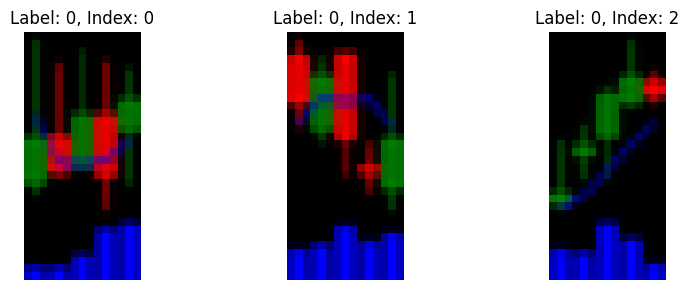

In [36]:
class StockImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert(PIL_MODE)
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label, idx


# Do NOT resize
basic_transform = transforms.Compose([
    transforms.Resize((32, 15)),
    transforms.ToTensor()
])

train_dataset = StockImageDataset(train_df, transform=basic_transform)
val_dataset   = StockImageDataset(val_df, transform=basic_transform)
test_dataset  = StockImageDataset(test_df, transform=basic_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    pin_memory=True
)

# Test one batch
images, labels, idx = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

# Plot 3 resulting images
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for i in range(3):
    image, label, idx = train_dataset[i]
    img_np = image.numpy()

    if img_np.shape[0] == 1:
        axes[i].imshow(img_np[0], cmap="gray")
    else:
        axes[i].imshow(np.transpose(img_np, (1, 2, 0)))

    axes[i].set_title(f"Label: {label}, Index: {idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

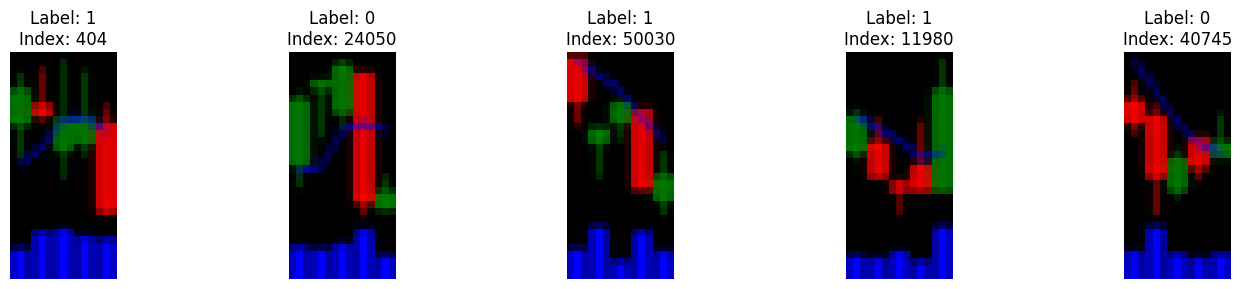

In [20]:
random_indices = random.sample(range(len(train_dataset)), 5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, idx in zip(axes, random_indices):
    image, label, dataset_idx = train_dataset[idx]
    img_np = image.numpy()

    if img_np.shape[0] == 1:
        ax.imshow(img_np[0], cmap="gray")
    else:
        ax.imshow(np.transpose(img_np, (1, 2, 0)))

    ax.set_title(f"Label: {label}\nIndex: {dataset_idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Hvis PyTorch bruger CPU i stedet for Nvidia GPU er det fordi du har installeret en CPU version af PyTorch. Så kan man køre følgende kommandoer for at få CUDA version med PyTorch
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [12]:
print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Python: c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
Torch CUDA version: 12.6
GPU count: 1
GPU name: NVIDIA GeForce RTX 4070


In [23]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        # Using padding='same' (requires recent PyTorch versions) to preserve spatial dimensions.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=(5, 3), padding='same')
        self.bn1 = nn.BatchNorm2d(64)
        self.act1 = nn.LeakyReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 1))

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(5, 3), padding='same')
        self.bn2 = nn.BatchNorm2d(128)
        self.act2 = nn.LeakyReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 1))

        self.dropout = nn.Dropout(p=0.5)
        # After two pooling layers:
        #   Input: 32x15
        #   After conv1 (same padding): 32x15, then pool1 (2x1): 16x15.
        #   After conv2 (same padding): 16x15, then pool2 (2x1): 8x15.
        # Flattened features: 128 * 8 * 15 = 15360.
        self.fc = nn.Linear(128 * 8 * 15, num_classes) # Jonas sendte dette men virker kun for 32x15
        # self.fc = nn.Linear(128 * 24 * 96, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.dropout(x)
        x = self.fc(x)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [37]:
PRINT_EVERY = 50

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels, _) in enumerate(loader, 1):
        if batch_idx % PRINT_EVERY == 0 or batch_idx == 1 or batch_idx == len(loader):
            print(f"    Batch {batch_idx}/{len(loader)}")
            
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SimpleCNN(
    #input_channels=INPUT_CHANNELS,
    #input_size=IMG_RESOLUTION,
    num_classes=2
).to(device)

print("Trainable params:", count_parameters(model))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

num_epochs = 50
patience = 2   # Jiang-style early stopping after 2 non-improving epochs
best_val_loss = float("inf")
patience_counter = 0

model_save_path = os.path.join(
    data_folder,
    f"best_jiang_baseline_i5_{COLOR_MODE}_{IMG_RESOLUTION}.pth"
)

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), model_save_path)
        print("  Saved best model.")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("  Early stopping triggered.")
            break

print("Best model path:", model_save_path)

Using device: cuda
Trainable params: 157058
    Batch 1/456
    Batch 50/456
    Batch 100/456
    Batch 150/456
    Batch 200/456
    Batch 250/456
    Batch 300/456
    Batch 350/456
    Batch 400/456
    Batch 450/456
    Batch 456/456
Epoch 1/50
  Train loss: 0.7519 | Train acc: 0.5150
  Val   loss: 0.6875 | Val   acc: 0.5481
  Saved best model.
    Batch 1/456
    Batch 50/456
    Batch 100/456
    Batch 150/456
    Batch 200/456
    Batch 250/456
    Batch 300/456
    Batch 350/456
    Batch 400/456
    Batch 450/456
    Batch 456/456
Epoch 2/50
  Train loss: 0.7360 | Train acc: 0.5281
  Val   loss: 0.6851 | Val   acc: 0.5550
  Saved best model.
    Batch 1/456
    Batch 50/456
    Batch 100/456
    Batch 150/456
    Batch 200/456
    Batch 250/456
    Batch 300/456
    Batch 350/456
    Batch 400/456
    Batch 450/456
    Batch 456/456
Epoch 3/50
  Train loss: 0.7249 | Train acc: 0.5356
  Val   loss: 0.6821 | Val   acc: 0.5620
  Saved best model.
    Batch 1/456
    Batch 50/456

In [38]:
# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(
    #input_channels=INPUT_CHANNELS,
    #input_size=IMG_RESOLUTION,
    num_classes=2
).to(device)

model_save_path = os.path.join(
    data_folder,
    f"best_jiang_baseline_i5_{COLOR_MODE}_{IMG_RESOLUTION}.pth"
)
model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc:  {test_acc:.4f}")

model.eval()

# Reset index so dataset idx matches dataframe row
test_df = test_df.reset_index(drop=True)

# Create empty column for predicted probability of "up"
test_df["pred_prob_up"] = None

with torch.no_grad():
    for images, labels, indices in test_loader:
        images = images.to(device)

        outputs = model(images)

        # Option A: convert 2 logits to probabilities
        probs_up = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()

        for i, idx in enumerate(indices.numpy()):
            test_df.loc[idx, "pred_prob_up"] = float(probs_up[i])

# Optional: also create predicted class from 0.5 threshold
test_df["pred_label"] = (test_df["pred_prob_up"].astype(float) >= 0.5).astype(int)

# Save file
predictions_path = os.path.join(data_folder, "test_predictions.csv")
test_df.to_csv(predictions_path, index=False)

print("Saved predictions to:", predictions_path)

Test loss: 0.6768
Test acc:  0.5760
Saved predictions to: res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0\test_predictions.csv


In [39]:
# ==========================================
# 1) True labels and model predictions
# ==========================================
test_true_labels = test_df["label"].to_numpy(dtype=int)
test_predicted_prob_up = test_df["pred_prob_up"].astype(float).to_numpy()
test_predicted_labels = (test_predicted_prob_up >= 0.5).astype(int)

# ==========================================
# 2) True class balances from each split
# ==========================================
train_true_up_rate = train_df["label"].mean()
val_true_up_rate = val_df["label"].mean()
test_true_up_rate = test_df["label"].mean()

# Combined train+val balance = development-set class prior
development_true_up_rate = (
    train_df["label"].sum() + val_df["label"].sum()
) / (len(train_df) + len(val_df))

# ==========================================
# 3) Model prediction distribution
# ==========================================
test_predicted_up_rate = test_predicted_labels.mean()

test_predicted_prob_up_min = test_predicted_prob_up.min()
test_predicted_prob_up_max = test_predicted_prob_up.max()
test_predicted_prob_up_mean = test_predicted_prob_up.mean()
test_predicted_prob_up_std = test_predicted_prob_up.std()

test_share_prob_below_50 = np.mean(test_predicted_prob_up < 0.5)
test_share_prob_at_or_above_50 = np.mean(test_predicted_prob_up >= 0.5)

print("=== True label balance ===")
print(f"Train up-rate                    = {train_true_up_rate:.1%}")
print(f"Val up-rate                      = {val_true_up_rate:.1%}")
print(f"Development up-rate (train+val)  = {development_true_up_rate:.1%}")
print(f"Test up-rate                     = {test_true_up_rate:.1%}")

print("\n=== Model prediction distribution on test set ===")
print(f"Predicted up-rate                = {test_predicted_up_rate:.1%}")
print(f"Min predicted prob(up)           = {test_predicted_prob_up_min:.4f}")
print(f"Max predicted prob(up)           = {test_predicted_prob_up_max:.4f}")
print(f"Mean predicted prob(up)          = {test_predicted_prob_up_mean:.2%}   bør være så tæt på Test up-rate som muligt")
print(f"Std of predicted prob(up)        = {test_predicted_prob_up_std:.4f}")
print(f"Share with prob(up) < 0.50       = {test_share_prob_below_50:.1%}")
print(f"Share with prob(up) >= 0.50      = {test_share_prob_at_or_above_50:.1%}")

# ==========================================
# 4) Classification metrics
# ==========================================
test_accuracy = accuracy_score(test_true_labels, test_predicted_labels)
test_balanced_accuracy = balanced_accuracy_score(test_true_labels, test_predicted_labels)
test_auc = roc_auc_score(test_true_labels, test_predicted_prob_up)
test_log_loss = log_loss(test_true_labels, test_predicted_prob_up)

print("\n=== Test classification metrics ===")
print(f"Test accuracy                    = {test_accuracy:.4f}")
print(f"Test balanced accuracy           = {test_balanced_accuracy:.4f}")
print(f"Test AUC                         = {test_auc:.4f}")
print(f"Test log loss                    = {test_log_loss:.4f}")

# ==========================================
# 5) Confusion matrix
# ==========================================
conf_matrix = confusion_matrix(test_true_labels, test_predicted_labels, labels=[0, 1])
true_negatives, false_positives, false_negatives, true_positives = conf_matrix.ravel()

test_recall_down = true_negatives / (true_negatives + false_positives) if (true_negatives + false_positives) > 0 else np.nan
test_recall_up = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else np.nan

print("\n=== Confusion matrix ===")
print(conf_matrix)
print(f"TN (true down predicted down)    = {true_negatives}")
print(f"FP (true down predicted up)      = {false_positives}")
print(f"FN (true up predicted down)      = {false_negatives}")
print(f"TP (true up predicted up)        = {true_positives}")
print(f"Recall for Down class            = {test_recall_down:.4f}")
print(f"Recall for Up class              = {test_recall_up:.4f}")


=== True label balance ===
Train up-rate                    = 54.4%
Val up-rate                      = 54.4%
Development up-rate (train+val)  = 54.4%
Test up-rate                     = 54.4%

=== Model prediction distribution on test set ===
Predicted up-rate                = 66.8%
Min predicted prob(up)           = 0.1511
Max predicted prob(up)           = 0.8034
Mean predicted prob(up)          = 53.43%   bør være så tæt på Test up-rate som muligt
Std of predicted prob(up)        = 0.0845
Share with prob(up) < 0.50       = 33.2%
Share with prob(up) >= 0.50      = 66.8%

=== Test classification metrics ===
Test accuracy                    = 0.5760
Test balanced accuracy           = 0.5618
Test AUC                         = 0.5898
Test log loss                    = 0.6768

=== Confusion matrix ===
[[2677 4032]
 [2201 5791]]
TN (true down predicted down)    = 2677
FP (true down predicted up)      = 4032
FN (true up predicted down)      = 2201
TP (true up predicted up)        = 5791
Reca

In [27]:
# ---- Grad-CAM helper ----
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[0, class_idx]

        self.model.zero_grad()
        score.backward()

        activations = self.activations[0]   # [C, H, W]
        gradients = self.gradients[0]       # [C, H, W]

        weights = gradients.mean(dim=(1, 2))  # [C]

        cam = torch.zeros(activations.shape[1:], device=activations.device)
        for c, w in enumerate(weights):
            cam += w * activations[c]

        cam = F.relu(cam)

        if cam.max() > 0:
            cam = cam / cam.max()

        cam = cam.unsqueeze(0).unsqueeze(0)
        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        return cam.squeeze().cpu().numpy(), output.detach()

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


# ---- choose last conv layer of JiangBaselineI5 ----
target_layer = model.features[4]   # Conv2d(64 -> 128), last conv layer
gradcam = GradCAM(model, target_layer)

# ---- pick 1 random test image ----
idx = random.randint(0, len(test_dataset) - 1)
image, label, row_idx = test_dataset[idx]
input_tensor = image.unsqueeze(0).to(device)

# ---- generate Grad-CAM ----
cam, logits = gradcam.generate(input_tensor)
probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
pred = int(np.argmax(probs))

# ---- print info ----
print(f"Random test index: {idx}")
print(f"True label:      {label}")
print(f"Predicted label: {pred}")
print(f"Prob down:       {probs[0]:.4f}")
print(f"Prob up:         {probs[1]:.4f}")

# ---- prepare image for plotting ----
img = image.detach().cpu().numpy()

if img.shape[0] == 1:
    img = img[0]   # grayscale -> [H, W]
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
else:
    img = np.transpose(img, (1, 2, 0))   # color -> [H, W, C]
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()

# ---- optional threshold to highlight only stronger regions ----
cam_plot = cam.copy()
cam_plot[cam_plot < 0.40] = 0.0

# ---- show original + Grad-CAM overlay ----
plt.figure(figsize=(6, 6))
if img.ndim == 2:
    plt.imshow(img, cmap="gray")
else:
    plt.imshow(img)
plt.imshow(cam_plot, cmap="Blues", alpha=0.45)
plt.title(f"Grad-CAM | true={label} pred={pred}")
plt.axis("off")
plt.show()

gradcam.remove_hooks()

AttributeError: 'SimpleCNN' object has no attribute 'features'